# The plot we used to show how N2V works

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch
import cv2
import numpy as np
from matplotlib.patches import ConnectionPatch

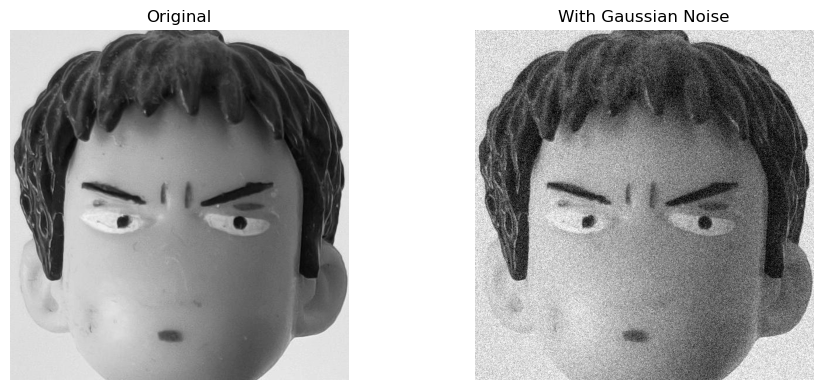

In [12]:
img = cv2.imread('./toy.jpg')
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_float = gray_img.astype(np.float32)

mean = 0
stddev = 25

noise = np.random.normal(mean, stddev, gray_img.shape).astype(np.float32)

noisy_img = img_float + noise

noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray_img,cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(noisy_img,cmap='gray')
plt.title('With Gaussian Noise')
plt.axis('off')
plt.tight_layout()
plt.show()

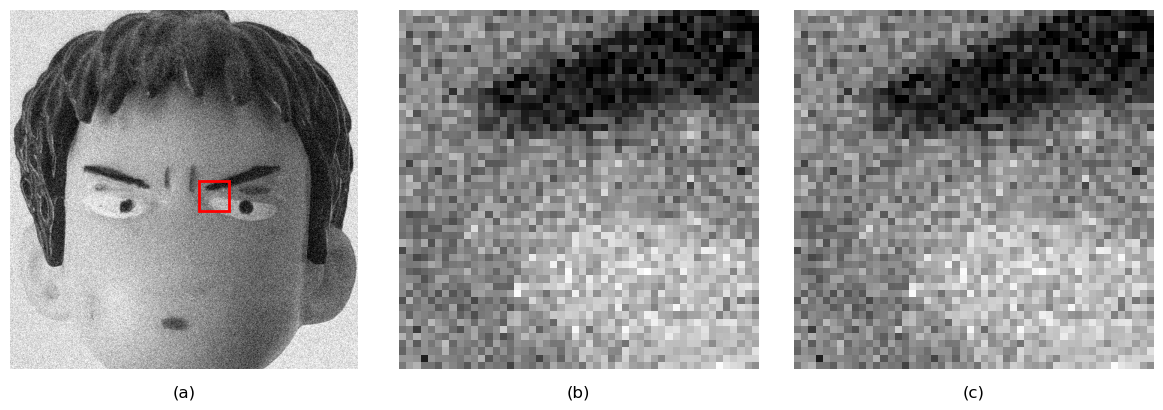

In [13]:
masked_img = noisy_img.copy()
masked_img[:150, :150] = 255 

x, y, w, h = 315, 285, 50, 50
crop = noisy_img[y:y+h, x:x+w] 
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].imshow(noisy_img,cmap='gray')
axs[0].add_patch(patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none'))
axs[0].set_title("(a)", y=-0.1)
axs[0].axis('off')

axs[1].imshow(crop,cmap='gray')
axs[1].set_title("(b)", y=-0.1)
axs[1].axis('off')

axs[2].imshow(crop,cmap='gray')
axs[2].add_patch(patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none'))
axs[2].set_title("(c)", y=-0.1)
axs[2].axis('off')

plt.tight_layout()
plt.show()

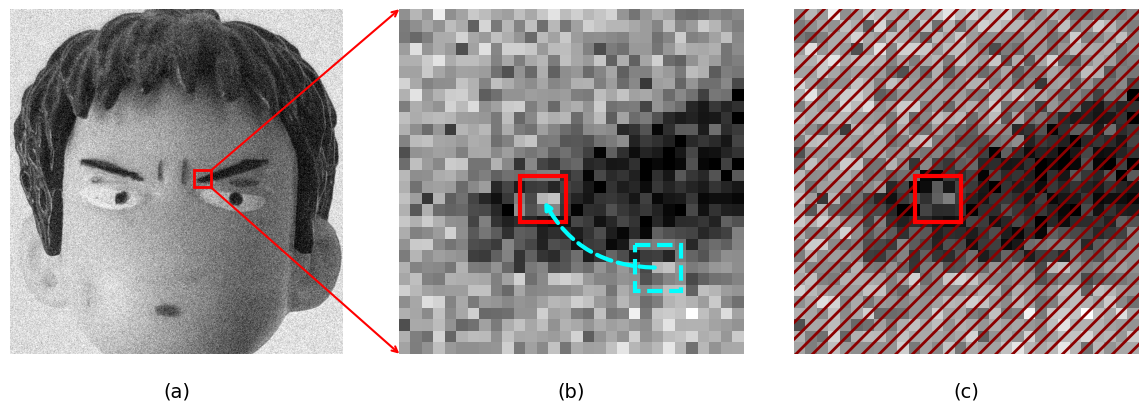

In [20]:
x, y, w, h = 320, 280, 30, 30
crop_orig = noisy_img[y:y+h, x:x+w].copy()

# Define the patch size and locations (relative to the 30x30 crop)
pw, ph = 4, 4  # Patch size
target_x, target_y = 10, 14  # Red box (Target) - put this right on the eyebrow edge
source_x, source_y = 20, 20  # Blue box (Source) - put this on plain skin

# 2. Fix the logic: Actually copy the pixels to simulate the Blind-spot mechanism!
crop_modified = crop_orig.copy()
crop_modified[target_y:target_y+ph, target_x:target_x+pw] = \
    crop_orig[source_y:source_y+ph, source_x:source_x+pw]

# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# (a): Original ---
axs[0].imshow(noisy_img, cmap='gray')
axs[0].add_patch(patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none'))
axs[0].set_title("(a)", y=-0.15, fontsize=14)
axs[0].axis('off')

# (b): Blind-spot generation (Modified Crop) ---
axs[1].imshow(crop_modified, cmap='gray')
# Draw Source (Blue) and Target (Red) boxes
axs[1].add_patch(patches.Rectangle((source_x, source_y), pw, ph, linewidth=3, linestyle="--",edgecolor='cyan', facecolor='none'))
axs[1].add_patch(patches.Rectangle((target_x, target_y), pw, ph, linewidth=3, edgecolor='red', facecolor='none'))

# Draw an arrow from Blue (source) to Red (target)
blue_cx, blue_cy = source_x + pw/2, source_y + ph/2
red_cx, red_cy = target_x + pw/2, target_y + ph/2
axs[1].annotate('', xy=(red_cx, red_cy), xytext=(blue_cx, blue_cy),
                arrowprops=dict(arrowstyle="->",linestyle="--", color="cyan", linewidth=3, connectionstyle="arc3,rad=-0.3"))
axs[1].set_title("(b)", y=-0.15, fontsize=14)
axs[1].axis('off')

con1 = ConnectionPatch(xyA=(x+w, y), coordsA=axs[0].transData,
                       xyB=(-0.5, -0.5), coordsB=axs[1].transData,
                       color="red", arrowstyle="->", linewidth=1.5)

con2 = ConnectionPatch(xyA=(x+w, y+h), coordsA=axs[0].transData,
                       xyB=(-0.5, h - 0.5), coordsB=axs[1].transData,
                       color="red", arrowstyle="->", linewidth=1.5)

fig.add_artist(con1)
fig.add_artist(con2)

axs[2].imshow(crop_orig, cmap='gray')

plt.rcParams['hatch.linewidth'] = 2.0 

axs[2].add_patch(patches.Rectangle((-0.5, -0.5), w, target_y + 0.5, 
                                   fill=False, hatch='//', color='darkred', alpha=1, linewidth=0))

axs[2].add_patch(patches.Rectangle((-0.5, target_y + ph), w, h - 0.5 - (target_y + ph), 
                                   fill=False, hatch='//', color='darkred', alpha=1, linewidth=0))

axs[2].add_patch(patches.Rectangle((-0.5, target_y), target_x + 0.5, ph, 
                                   fill=False, hatch='//', color='darkred', alpha=1, linewidth=0))

axs[2].add_patch(patches.Rectangle((target_x + pw, target_y), w - 0.5 - (target_x + pw), ph, 
                                   fill=False, hatch='//', color='darkred', alpha=1, linewidth=0))

axs[2].add_patch(patches.Rectangle((target_x, target_y), pw, ph, 
                                   linewidth=3, edgecolor='red', facecolor='none'))

axs[2].set_title("(c)", y=-0.15, fontsize=14)
axs[2].axis('off')

plt.tight_layout()
plt.savefig("/data/aai/scratch/jchan/denoise/PAUS/output_save/N2Vworking.pdf", format="pdf", bbox_inches="tight")
plt.show()